**Másteres Universitarios en Ciencia de Datos y en Sistemas Interactivos Inteligentes, UAM**
## **Procesamiento del Lenguaje Natural**
# **Práctica de laboratorio 5: Ajuste fino de BERT para análisis de sentimientos**





---

**Pareja de prácticas:** [14]  
**Miembros:** [xiaoyong wang and chenghu yang]

---

En esta práctica, vamos a ajustar (hacer *fine-tuning* de) BERT para la tarea de análisis de sentimiento de la práctica 4.

Al hacerlo, estaremos posibilitando la transferencia de aprendizaje (*transfer learning*) de un modelo de lenguaje preentrenado, lo cual ha quedado demostrado ser una estrategia exitosa para lograr rendimientos de última generación en tareas de procesamiento del lenguaje natural.

Aprenderemos lo siguiente:

*   Ajustar modelos transformers de la biblioteca [Hugging Face](https://github.com/huggingface/transformers).
*   Preprocesar datos para la arquitectura de transformers (tokenización de subpalabras con WordPiece).
*   Implementar un clasificador basado en BERT.

Como aprendimos en la clase de teoría, utilizaremos el conocimiento codificado en el Transformer para mejorar el aprendizaje de nuestra tarea objetivo. Así, nuestro clasificador de sentimientos tendrá dos componentes principales:

*   El codificador de texto (encoder) BERT, que no sabe nada sobre sentimientos, pero sí sobre el idioma inglés.
*   Un componente dedicado a la clasificación de sentimientos, que será una capa feed-forward.

BERT generará los embeddings para las oraciones entrada y los pasará a la capa de clasificación. Cuando ajustemos el clasificador, también modificaremos los parámetros de BERT para que aprenda aspectos específicos de la tarea.

Ventajas de esta arquitectura y del aprendizaje por transferencia:

*   Se puede recopilar una cantidad ilimitada de texto no etiquetado desde la web con muy poco esfuerzo para entrenar un modelo de lenguaje a gran escala.
*   Transformer es una arquitectura feed-forward que permite un entrenamiento altamente paralelizado y eficiente en conjuntos de datos masivos, con el objetivo de predecir palabras basadas en su contexto ([consulta el tutorial sobre estrategias de aprendizaje para clasificación de secuencias](https://colab.research.google.com/drive/1yWaLpCWImXZE2fPV0ZYDdWWI8f52__9A#scrollTo=MGqVkG2-7qfu)).
*   Aunque el preentrenamiento de un modelo de lenguaje puede ser costoso, el *fine-tuning* generalmente puede realizarse en una sola GPU, ya que típicamente requiere pocas épocas de entrenamiento.

## 1. Carga de los datos
Usaremos los mismos datos de análisis de sentimiento que en la práctica anterior. Por lo tanto, primero necesitamos montar nuestra cuenta de Google Drive, y después acceder al Stanford Sentiment Treebank (SST).

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import numpy as np
import pandas as pd
import re

import tensorflow as tf
from sklearn.utils import shuffle

## Fijamos semillas de generación de números aleatorios para replicabilidad de resultados
np.random.seed(1)
tf.random.set_seed(2)

# Utilizamos el Stanford Sentiment Treebank (SST) como corpus de prueba para análisis de sentimientos de textos
# Cargamos y procesamos los datos para tratarlos como un problema de clasificación binaria de sentimientos
# Convertimos la escala de sentimientos de [1,5] a {0,1}
def load_sst_data(path,
                  easy_label_map={0:0, 1:0, 2:None, 3:1, 4:1}):
    data = []
    with open(path) as f:
        for i, line in enumerate(f):
            example = {}
            example['label'] = easy_label_map[int(line[1])]
            if example['label'] is None:
                continue

            text = re.sub(r'\s*(\(\d)|(\))\s*', '', line)
            example['text'] = text[1:]
            data.append(example)
    data = pd.DataFrame(data)
    return data

def pretty_print(example):
    print('Label: {}\nText: {}'.format(example['label'], example['text']))

sst_home = '/content/drive/MyDrive/lab/data'
# Verify the path before loading data
import os
if not os.path.exists(sst_home):
    print(f"Error: Directory {sst_home} does not exist.")
    print("Please check the path in your Google Drive.")
else:
    print(f"Contents of {sst_home}:")
    print(os.listdir(sst_home))

training_set = load_sst_data(sst_home+'/sst_training.txt')
validation_set = load_sst_data(sst_home+'/sst_validation.txt')
test_set = load_sst_data(sst_home+'/sst_test.txt')

# Desordenamos los datos
training_set = shuffle(training_set)
validation_set = shuffle(validation_set)
test_set = shuffle(test_set)

# Obtenemos los vectores de texto y etiquetas (clases de opinión: positiva y negativa)
train_texts = training_set.text
train_labels = training_set.label

validation_texts = validation_set.text
validation_labels = validation_set.label

test_texts = test_set.text
test_labels = test_set.label

print('Tamaño del conjunto de entrenamiento: {}'.format(len(training_set)))
print('Tamaño del conjunto de validación: {}'.format(len(validation_set)))
print('Tamaño del conjunto de test: {}'.format(len(test_set)))

Contents of /content/drive/MyDrive/lab/data:
['sst_test.txt', 'sst_validation.txt', 'sst_training.txt']
Tamaño del conjunto de entrenamiento: 6920
Tamaño del conjunto de validación: 872
Tamaño del conjunto de test: 1821


## 2. Instalación y configuración de la librería Transformers
Para usar la librería Transformers, deberemos registrarnos en Hugging Face y obtener una API key, que llamaremos HF_TOKEN. Esta clave nos permitirá acceder a modelos preentrenados y otros recursos de Hugging Face.

Para guardar y activar HF_TOKEN en Google Colab:


1.   Accede a Hugging Face Tokens y genera un nuevo token de acceso con permisos de lectura.
2.   Para evitar compartir tu clave de acceso en el código Python, puedes añadir HF_TOKEN como un "secreto" en Google Colab. Para hacerlo, sigue estos pasos:
    *   En Google Colab, haz clic en el icono de su panel de control en la parte izquierda.
    *   Luego, selecciona la pestaña "Secretos".
    *   Haz clic en "Nuevo secreto" y en el campo "Nombre" escribe HF_TOKEN. En el campo "Valor", pega tu clave de Hugging Face que obtuviste en el paso 1.

Después de guardar el secreto, en el código podrías acceder al valor de HF_TOKEN como sigue:
```
import os
HF_TOKEN = os.getenv('HF_TOKEN')
from huggingface_hub import login
login(HF_TOKEN)
```

De esta manera, usarías la clave de manera segura y acceder a modelos y datasets de Hugging Face sin exponerla directamente en el código. Si has añadido HF_TOKEN en "Secretos" de Google Colab, no es necesario añadir las instrucciones anteriores en el código.

In [3]:
!pip install -q transformers==4.44.2 tensorflow

Una vez que la librería Transformers está instalada, podemos utilizarla directamente creando objetos de las siguientes clases:

- La clase **tokenizer**: se encarga de convertir una secuencia de entrada en tensores de enteros, que son índices en el vocabulario de un modelo. La tokenización varía según el modelo, ya que cada modelo tiene su propio tokenizer.

- La clase **model**: contiene la lógica del modelo de red neuronal en sí. Al utilizar un modelo de TensorFlow, hereda de tf.keras.layers.Layer, lo que significa que se puede usar de manera muy sencilla con la API fit de Keras o para hacer cosas más complicadas.

También existe una clase de configuración (**configuration**), que es necesaria a menos que no se estén utilizando los valores predeterminados. Con esta clase indicamos todo lo relacionado con los hiperparámetros del modelo, como el número de capas, dropout, etc. A continuación, se muestra un ejemplo de un archivo de configuración de BERT, para los pesos preentrenados bert-base-cased.

```
{
  "attention_probs_dropout_prob": 0.1,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "max_position_embeddings": 512,
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "type_vocab_size": 2,
  "vocab_size": 28996
}
```


Específicamente, importamos las clases `TFBertForSequenceClassification` y `BertTokenizer` desde la librería transformers. Utilizamos el método `from_pretrained` para cargar el modelo BERT preentrenado, en este caso el modelo "bert-base-uncased", que es una versión de BERT entrenada sin distinción de mayúsculas y minúsculas.


*   La variable `model` contiene el modelo BERT adaptado para tareas de clasificación de secuencias, que es el caso que nos interesa aquí pues buscamos clasificar de forma binaria oraciones atendiendo a sus polaridades de sentimiento, positiva o negativa.
*   Por su parte, el `tokenizer` es el que fue empleado para construir BERT, y el que utilizaremos para convertir el texto de entrada en tensores de índices que el modelo puede procesar.

In [4]:
import tensorflow as tf
from transformers import TFBertForSequenceClassification, BertTokenizer

try:
    model = TFBertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)
    tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
    print("Modelo y Tokenizer cargados con éxito.")
except Exception as e:
    print(f"Error: {e}")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

All PyTorch model weights were used when initializing TFBertForSequenceClassification.

Some weights or buffers of the TF 2.0 model TFBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Modelo y Tokenizer cargados con éxito.


/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


⬛
#### EJERCICIO 1
Atendiendo a lo aprendido en la clase de teoría y a información disponible en la web, ¿cuál es la arquitectura interna de `TFBertForSequenceClassification` con respecto a la de `TFBertModel`?

`TFBertModel` es el *backbone* de BERT: devuelve representaciones de secuencia (`last_hidden_state`), el estado del token `[CLS]` pasado por una capa densa + tanh (`pooler_output`), y opcionalmente los *hidden states* intermedios.

`TFBertForSequenceClassification` **envuelve** a `TFBertModel` y añade una cabeza de clasificación: típicamente *dropout* sobre el vector *pooled* (representación de `[CLS]`) y una capa lineal (`Dense`) que proyecta a `num_labels` logits. Es decir, la diferencia es la **cabeza feed-forward para la tarea downstream** y la configuración del número de clases; el encoder BERT es el mismo componente base.

## 3. Preprocesado de los textos
A continuación, definimos dos funciones auxiliares para 1) extraer características del tokenizer (`convert_examples_to_features`) y 2) convertir las características en un objeto de la clase `tf.data.Dataset `(`convert_features_to_tf_dataset`).

`tf.data.Dataset` ayuda a gestionar e iterar de manera eficiente los datos de entrada y salida del modelo. Para más información, puedes consultar la API en la página web de TensorFlow: https://www.tensorflow.org/api_docs/python/tf/data/Dataset.

Con esas funciones preprocesamos los conjuntos de entrenamiento y validación. Usamos `tf.data.Dataset` para establecer el tamaño de lote en 32.

In [5]:
from transformers import InputFeatures

def convert_examples_to_features(texts, labels):
  labels = list(labels)
  batch_encoding = tokenizer.batch_encode_plus(texts, max_length=128, padding='max_length', truncation=True)

  features = []
  for i in range(len(texts)):
      inputs = {k: batch_encoding[k][i] for k in batch_encoding}

      feature = InputFeatures(**inputs, label=labels[i])
      features.append(feature)

  for i, example in enumerate(texts[:5]):
      print("*** Ejemplo ***")
      print("texto: %s" % (example))
      print("características: %s" % features[i])

  return features

def convert_features_to_tf_dataset(features):
  def gen():
      for ex in features:
          yield (
              {
                  "input_ids": ex.input_ids,
                  "attention_mask": ex.attention_mask,
                  "token_type_ids": ex.token_type_ids,
              },
              ex.label,
          )
  dataset = tf.data.Dataset.from_generator(gen,
                                           ({"input_ids": tf.int32, "attention_mask": tf.int32, "token_type_ids": tf.int32}, tf.int64),
                                           (
                                               {
                                                "input_ids": tf.TensorShape([None]),
                                                "attention_mask": tf.TensorShape([None]),
                                                "token_type_ids": tf.TensorShape([None])
                                                },
                                            tf.TensorShape([]),
                                            ))
  return dataset

train_features = convert_examples_to_features(train_texts, train_labels)
train_dataset = convert_features_to_tf_dataset(train_features)

validation_features = convert_examples_to_features(validation_texts, validation_labels)
validation_dataset = convert_features_to_tf_dataset(validation_features)

train_dataset = train_dataset.shuffle(100).batch(32)
validation_dataset = validation_dataset.batch(32)

# Visualizamos un bacth de 32 ejemplos
#instance = list(train_dataset.take(1).as_numpy_iterator())
#print(instance)

*** Ejemplo ***
texto: It is dark , brooding and slow , and takes its central idea way too seriously .
características: InputFeatures(input_ids=[101, 2009, 2003, 2601, 1010, 28902, 1998, 4030, 1010, 1998, 3138, 2049, 2430, 2801, 2126, 2205, 5667, 1012, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], attention_mask=[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], token_type_id

⬛
#### EJERCICIO 2
¿Qué es lo que hace y retorna como salida la función `tokenizer.batch_encode_plus`?

`batch_encode_plus` toma una **lista de textos** (o pares) y aplica el pipeline de tokenización de BERT en lote: segmentación WordPiece, inserción de tokens especiales (`[CLS]`, `[SEP]`, etc.), conversión a IDs, *padding* y *truncado* según los argumentos (`max_length`, `pad_to_max_length` / `padding`, etc.).

**Retorna** un diccionario (objeto tipo *BatchEncoding*) con tensores o listas alineadas por ejemplo, en particular `input_ids`, `attention_mask` y `token_type_ids` (en tareas de una sola oración, `token_type_ids` suele ser todo ceros). Esas claves son las que el modelo espera como entrada.

## 4. Entendiendo el tokenizer

Cuando preprocesamos el texto de entrada para ser introducido en un encoder como BERT, típicamente seguimos tres pasos:

1.   Dividir las palabras en tokens (subwords).
2.   Agregar los tokens especiales como [CLS] y [SEP]. Estos tokens especiales ya están incluidos en el vocabulario del modelo, por lo que tienen su propio identificador de token.
3.   Sustituir los tokens por sus identificadores correspondientes. Después de este paso, obtenemos la forma adecuada para BERT.

El siguiente código muestra los resultados de estos tres pasos.



In [6]:
sentence1 = "A visually stunning rumination on love."
sentence2 = "There ought to be a directing license, so that Ed Burns can have his revoked."

print('0. INPUT SENTENCE: {}'.format(sentence1))

# Tokenizamos una oración
sentence1_tokenized = tokenizer.tokenize(sentence1)
print('1. TOKENIZED SENTENCE: {}'.format(sentence1_tokenized))

# Añadimos tokens especiales
sentence1_tokenized_with_special_tokens = ['[CLS]'] + sentence1_tokenized + ['[SEP]']
print('2. ADD [CLS], [SEP]: {}'.format(sentence1_tokenized_with_special_tokens))

# Convertimoa los tokens a ids
sentence1_ids = tokenizer.convert_tokens_to_ids(sentence1_tokenized_with_special_tokens)
print('3. SENTENCE IDS: {}'.format(sentence1_ids))

0. INPUT SENTENCE: A visually stunning rumination on love.
1. TOKENIZED SENTENCE: ['a', 'visually', 'stunning', 'rum', '##ination', 'on', 'love', '.']
2. ADD [CLS], [SEP]: ['[CLS]', 'a', 'visually', 'stunning', 'rum', '##ination', 'on', 'love', '.', '[SEP]']
3. SENTENCE IDS: [101, 1037, 17453, 14726, 19379, 12758, 2006, 2293, 1012, 102]


⬛
#### EJERCICIO 3
¿Qué le ocurrió a "rumination" después de la tokenización? ¿Por qué?
¿Cuáles son los identificadores de los tokens [CLS] y [SEP]?
¿De dónde vienen los identificadores de token?

- **"rumination"**: Con WordPiece, palabras poco frecuentes o largas se dividen en **subpalabras** con prefijo `##`. Aquí suele quedar algo como `rum` + `##ination`, porque esas piezas están en el vocabulario entrenado y la palabra entera puede no estarlo o ser más eficiente trocearla así.

- **`[CLS]` y `[SEP]`**: En `bert-base-uncased` los IDs son **101** y **102** (comprueba con `tokenizer.cls_token_id` y `tokenizer.sep_token_id`).

- **Origen de los IDs**: Provienen del **vocabulario fijo** del tokenizer (archivo `vocab.txt` asociado al modelo): cada token o subtoken tiene un índice entero. Los especiales se añadieron al vocabulario en el preentrenamiento.

Los tres pasos se pueden realizar con las funciones `encode` o `batch_encode_plus`.

In [7]:
sentence1_ids = tokenizer.encode(sentence1, add_special_tokens=True)
print('SENTENCE IDS: {}'.format(sentence1_ids))

batch_encoding = tokenizer.batch_encode_plus(
        [sentence1], max_length=128, padding='max_length', truncation=True,
    )
print('ENCODE PLUS: {}'.format(batch_encoding))

SENTENCE IDS: [101, 1037, 17453, 14726, 19379, 12758, 2006, 2293, 1012, 102]
ENCODE PLUS: {'input_ids': [[101, 1037, 17453, 14726, 19379, 12758, 2006, 2293, 1012, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]], 'token_type_ids': [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]], 'attention_mask': [[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,

⬛
#### EJERCICIO 4
¿Qué diferencias hay entre las funciones `tokenizer.encode` y `tokenizer.batch_encode_plus`?

- **`encode`**: Procesa **una sola** secuencia (o un par con `text_pair`). Devuelve **una lista de enteros** (IDs), sin el envoltorio de diccionario por lote.

- **`batch_encode_plus`**: Procesa **varias** secuencias a la vez (lista de strings o de pares). Devuelve un **diccionario** con listas/tensores por campo (`input_ids`, `attention_mask`, `token_type_ids`, …), listo para convertir a tensores y apilar en *batch*. Además permite control explícito de *padding*, longitud máxima y truncado en lote.

En resumen: una oración vs. lote; lista de IDs vs. estructura clave-valor para entrenamiento por *mini-batches*.

### Dos oraciones como entrada

Como hemos visto en la clase de teoría, BERT es un modelo de lenguaje enmascarado que aprende prediciendo palabras ocultas y, además, determina si una segunda oración sigue a una primera. Por esta razón, el tokenizer de BERT está diseñado para aceptar dos oraciones como entrada. Este tipo de preprocesamiento de datos es especialmente útil para tareas como similitud textual semántica (*semantic textual similarit*y), inferencia en lenguaje natural (*natural language inference*, *textual entailment*), o búsqueda de respuesta (*question answering*).

In [8]:
sentence_pair_ids = tokenizer.encode(text=sentence1, text_pair=sentence2, add_special_tokens=True)
batch_encoding = tokenizer.batch_encode_plus(
        [(sentence1, sentence2)], max_length=128, padding='max_length', truncation=True,
    )

print("SENTENCE PAIR IDS: {}".format(sentence_pair_ids))

SENTENCE PAIR IDS: [101, 1037, 17453, 14726, 19379, 12758, 2006, 2293, 1012, 102, 2045, 11276, 2000, 2022, 1037, 9855, 6105, 1010, 2061, 2008, 3968, 7641, 2064, 2031, 2010, 22837, 1012, 102]


⬛
#### EJERCICIO 5
¿Qué IDs corresponden a la primera oración y cuáles a la segunda? ¿Cómo quedan separados?



Con `add_special_tokens=True` el formato es: **`[CLS]` + tokens(oración1) + `[SEP]` + tokens(oración2) + `[SEP]`**.

- Los IDs que van **después del primer `[SEP]`** (excluyendo ese separador) corresponden a la **segunda oración**; todo lo situado **entre `[CLS]` y el primer `[SEP]`** corresponde a la **primera** (incluyendo subtokens).

- **`token_type_ids`** marcan el segmento: **0** para la primera oración (y `[CLS]`), **1** para la segunda (hasta el `[SEP]` final). Así el modelo distingue qué token pertenece a cada frase en tareas de pares.

Ejemplo (tal como imprime el notebook):
- `SENTENCE PAIR IDS: [101, 1037, 17453, 14726, 19379, 12758, 2006, 2293, 1012, 102, 2045, 11276, 2000, 2022, 1037, 9855, 6105, 1010, 2061, 2008, 3968, 7641, 2064, 2031, 2010, 22837, 1012, 102]`

Con este ejemplo:
- Primera oración (entre `[CLS]=101` y el primer `[SEP]=102`, excluyendo ambos): `[1037, 17453, 14726, 19379, 12758, 2006, 2293, 1012]`
- Segunda oración (entre el primer `[SEP]=102` y el `[SEP]` final, excluyendo ambos): `[2045, 11276, 2000, 2022, 1037, 9855, 6105, 1010, 2061, 2008, 3968, 7641, 2064, 2031, 2010, 22837, 1012]`

Con tus resultados de entrenamiento (3 épocas), el patrón encaja con sobreajuste incipiente: el `loss` de entrenamiento baja de forma clara y `accuracy` sube, pero el `val_loss` aumenta de manera continua y la `val_accuracy` se mantiene casi plana (apenas baja frente a la época 1). Según la referencia, esto significa que mejorar el entrenamiento no está traduciendo en una mejor generalización en validación; por eso conviene elegir epochs mirando ambas curvas.

## 5. Ajuste fino (fine-tuning) de BERT como un clasificador de oraciones

Una característica interesante al ajustar un modelo grande es que no necesitamos entrenar durante muchas épocas.

In [9]:
optimizer = tf.keras.optimizers.Adam(learning_rate=3e-5, epsilon=1e-08, clipnorm=1.0)
loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
metric = tf.keras.metrics.SparseCategoricalAccuracy('accuracy')
model.compile(optimizer=optimizer, loss=loss, metrics=[metric])

history = model.fit(train_dataset, epochs=3, validation_data=validation_dataset)

Epoch 1/3
217/217 [==============================] - 246s 834ms/step - loss: 0.3511 - accuracy: 0.8455 - val_loss: 0.2235 - val_accuracy: 0.9128
Epoch 2/3
217/217 [==============================] - 179s 824ms/step - loss: 0.1372 - accuracy: 0.9509 - val_loss: 0.2649 - val_accuracy: 0.9094
Epoch 3/3
217/217 [==============================] - 179s 827ms/step - loss: 0.0539 - accuracy: 0.9822 - val_loss: 0.3882 - val_accuracy: 0.9083


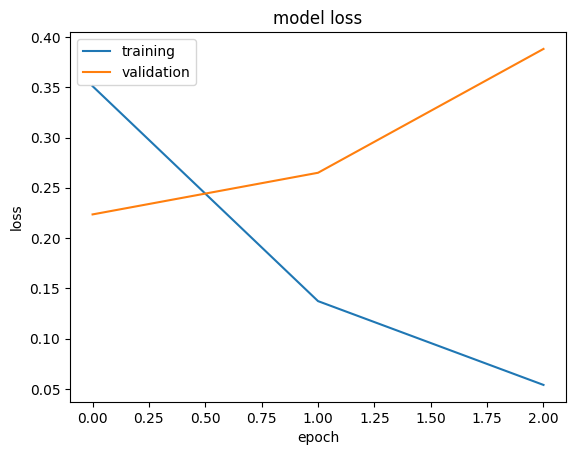

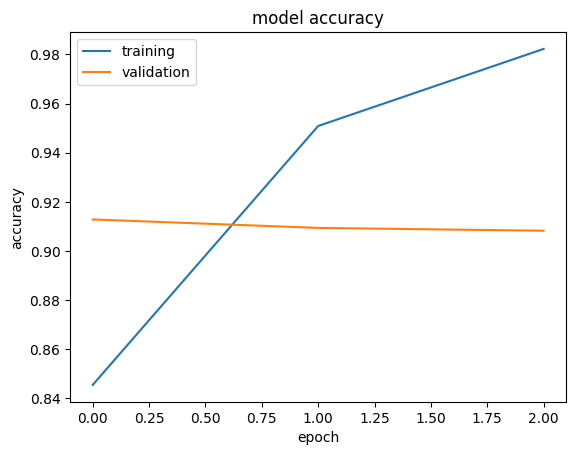

In [10]:
import matplotlib.pyplot as plt

# Visiualizamos el loss sobre los conjuntos de entrenamiento y validación en las 3 épocas de entranmiento
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['training', 'validation'], loc='upper left')
plt.show()

# Visiualizamos el accuracy sobre los conjuntos de entrenamiento y validación en las 3 épocas de entranmiento
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['training', 'validation'], loc='upper left')
plt.show()

⬛
#### EJERCICIO 6
Una vez que el modelo esté ajustado para el análisis de sentimientos, podemos evaluarlo en el conjunto de test. Para ello, también necesitamos tokenizar la entrada y convertirla a IDs. Escribe a continuación el código correspondiente.

In [11]:
# Mismo preprocesado que en entrenamiento / validación
test_features = convert_examples_to_features(test_texts, test_labels)
test_dataset = convert_features_to_tf_dataset(test_features).batch(32)

test_loss, test_accuracy = model.evaluate(test_dataset, verbose=1)
print(f"Test loss: {test_loss:.4f} | Test accuracy: {test_accuracy:.4f}")

*** Ejemplo ***
texto: With Danilo Donati 's witty designs and Dante Spinotti 's luscious cinematography , this might have made a decent children 's movie -- if only Benigni had n't insisted on casting himself in the title role .
características: InputFeatures(input_ids=[101, 2007, 19522, 4135, 24260, 3775, 1005, 1055, 25591, 5617, 1998, 9649, 6714, 21325, 1005, 1055, 11320, 11020, 6313, 16434, 1010, 2023, 2453, 2031, 2081, 1037, 11519, 2336, 1005, 1055, 3185, 1011, 1011, 2065, 2069, 28378, 2072, 2018, 1050, 1005, 1056, 7278, 2006, 9179, 2370, 1999, 1996, 2516, 2535, 1012, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], attention_mask=[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,

⬛
#### EJERCICIO 7
Considerar el modelo `TFBertModel` en vez de `TFBertForSequenceClassification`.

Modifica la arquitectura de `TFBertModel` para replicar los resultados obtenidos por `TFBertForSequenceClassification` en el ejercicio 5.

Para ello, tienes que añadir una capa feed-forward para clasificación binaria, que reciba como entrada la representación del token [CLS] generada por `TFBertModel`. Además, debes especificar las entadas `input_ids`, `attention_mask` y `token_type_ids`, así como decidir si añades `dropout` al clasificador, y si usas alternativas a `optimizer` y `loss`.

En la implementación que hiciste, la cabeza usa `pooler_output` (representación asociada a `[CLS]`), sobre la que aplicas `Dropout(0.1)` y luego una `Dense(2)` para producir los logits de las 2 clases. También se mantienen los mismos hiperparámetros que en el ejercicio 5: `Adam(learning_rate=3e-5, epsilon=1e-8, clipnorm=1.0)` y `SparseCategoricalCrossentropy(from_logits=True)` (no se probaron alternativas de `optimizer` ni de `loss`), de modo que la comparación es justa. En las curvas de validación se observa que `val_loss` empeora con claridad hacia la época 3, mientras que `val_accuracy` se mantiene y de hecho mejora ligeramente (por ejemplo, ≈0.898 → 0.905 → 0.916). Esto indica que la frontera de decisión sigue siendo razonable (accuracy no cae), pero que la pérdida empeora en validación, lo que sugiere un ajuste/probabilidades menos favorables (posible sobreajuste incipiente en calibración), por lo que conviene mirar `val_loss` y `val_accuracy` en conjunto.

In [12]:
from transformers import TFBertModel

# Cabeza de clasificación sobre el vector pooled del token [CLS] (misma lógica que en TFBertForSequenceClassification)
max_len = 128

input_ids = tf.keras.Input(shape=(max_len,), dtype=tf.int32, name="input_ids")
attention_mask = tf.keras.Input(shape=(max_len,), dtype=tf.int32, name="attention_mask")
token_type_ids = tf.keras.Input(shape=(max_len,), dtype=tf.int32, name="token_type_ids")

bert_backbone = TFBertModel.from_pretrained("bert-base-uncased")
bert_outputs = bert_backbone(
    input_ids=input_ids,
    attention_mask=attention_mask,
    token_type_ids=token_type_ids,
)
pooled_output = bert_outputs.pooler_output
x = tf.keras.layers.Dropout(0.1)(pooled_output)
logits = tf.keras.layers.Dense(2, name="classifier")(x)

model = tf.keras.Model(
    inputs={
        "input_ids": input_ids,
        "attention_mask": attention_mask,
        "token_type_ids": token_type_ids,
    },
    outputs=logits,
)

# Mismo esquema que arriba: Adam + entropía cruzada en logits + accuracy sparse
optimizer = tf.keras.optimizers.Adam(learning_rate=3e-5, epsilon=1e-08, clipnorm=1.0)
loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
metric = tf.keras.metrics.SparseCategoricalAccuracy("accuracy")
model.compile(optimizer=optimizer, loss=loss, metrics=[metric])

history = model.fit(train_dataset, epochs=3, validation_data=validation_dataset)

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertModel: ['cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.dense.weight', 'cls.predictions.bias', 'cls.seq_relationship.weight', 'cls.predictions.transform.LayerNorm.weight', 'cls.seq_relationship.bias']
- This IS expected if you are initializing TFBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFBertModel for predictions w

Epoch 1/3
217/217 [==============================] - 234s 854ms/step - loss: 0.3485 - accuracy: 0.8504 - val_loss: 0.2446 - val_accuracy: 0.8979
Epoch 2/3
217/217 [==============================] - 180s 828ms/step - loss: 0.1305 - accuracy: 0.9520 - val_loss: 0.2768 - val_accuracy: 0.9048
Epoch 3/3
217/217 [==============================] - 179s 826ms/step - loss: 0.0567 - accuracy: 0.9796 - val_loss: 0.3704 - val_accuracy: 0.9163


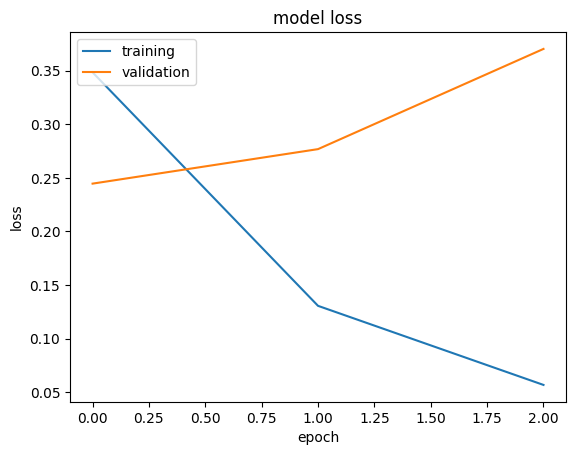

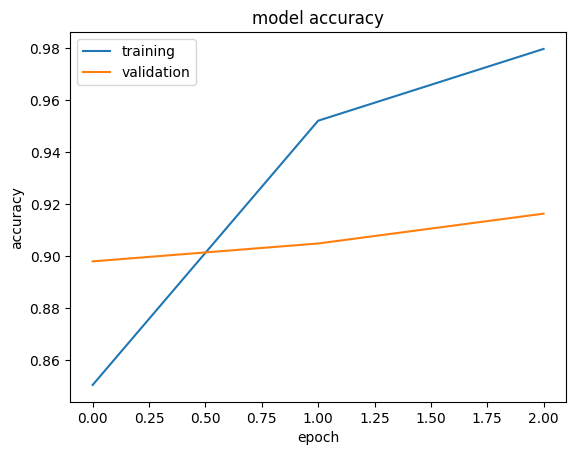

In [13]:
# Visiualizamos el loss sobre los conjuntos de entrenamiento y validación en las 3 épocas de entranmiento
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['training', 'validation'], loc='upper left')
plt.show()

# Visiualizamos el accuracy sobre los conjuntos de entrenamiento y validación en las 3 épocas de entranmiento
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['training', 'validation'], loc='upper left')
plt.show()